In [102]:
import pandas as pd 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.decomposition import PCA



In [95]:
df = pd.read_csv("../data/processed/clean_data.csv")

In [96]:
numeric_colones= [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
categoral_colones =[
    "SeniorCitizen",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]
pre = ColumnTransformer(
    transformers =[
        ('num',StandardScaler(),numeric_colones),
        ('cat',OneHotEncoder(handle_unknown="ignore"),categoral_colones)
    ]
)
X_prepared = pre.fit_transform(df)

Certaines variables ont été retirées afin de limiter la redondance et de conserver les caractéristiques les plus pertinentes pour la segmentation des clients. La variable ``` gender```  a été supprimée car elle apporte peu d'information sur le comportement d'utilisation des services. ```PhoneService``` a également été retirée car elle est fortement liée à MultipleLines, ce qui peut introduire une information redondante. 

2 => 0.2888353232794971 => 1.1741774561799598 => 2524.700670640071
3 => 0.28860069992236426 => 1.4472016772015346 => 2779.515553115482
4 => 0.23919488729027436 => 1.7548279537461964 => 2261.5729148007213
5 => 0.2211773636807385 => 1.903648825366978 => 1927.6303901581284
6 => 0.18450584339293663 => 1.8621302616472366 => 1691.7474252471336
7 => 0.16313284214476154 => 1.906169188434818 => 1523.6622666576295
8 => 0.15235156074595466 => 2.038541914509625 => 1386.6854043465646
9 => 0.15074306118153483 => 2.08406452379009 => 1274.375447483771
10 => 0.15285685965042609 => 2.1426124351771194 => 1173.519811892275


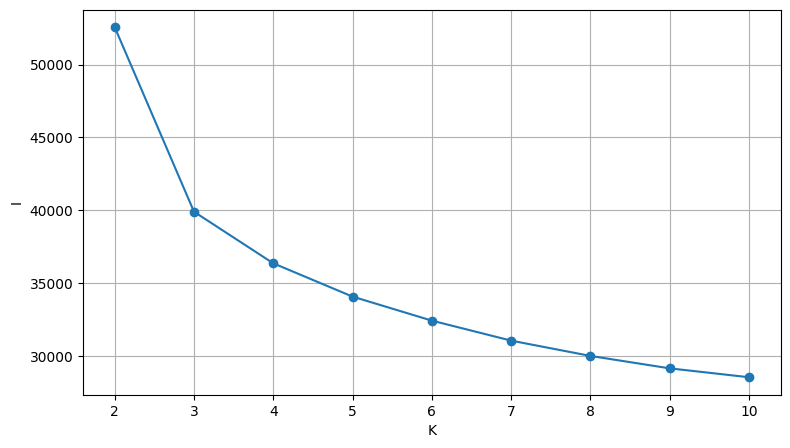

In [97]:
k_values = range(2, 11)
inertie = []
silhouette_scores =[]

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_prepared)

    score = silhouette_score(
        X_prepared,labels
    )
    db_score = davies_bouldin_score(
        X_prepared,
        labels
    )

    ch_score = calinski_harabasz_score(
        X_prepared,
        labels
    )
    silhouette_scores.append(score)
    inertie.append(model.inertia_)

    print(f"{k} => {score} => {db_score} => {ch_score}")



plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertie, marker="o")

plt.xlabel("K")
plt.ylabel("I")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# k = 3

In [98]:
dbscan = DBSCAN(
    eps=2.5,
    min_samples=5
)

lable = dbscan.fit_predict(X_prepared)

silhouette_score_DBSCAN = silhouette_score(
    X_prepared,lable
)
db_score_dbSCAN = davies_bouldin_score(
    X_prepared,
    lable
)
ch_score_db_scan = calinski_harabasz_score(
    X_prepared,
    lable
)
print("silhoutee : ",silhouette_score_DBSCAN)
print("Davies-Bouldin : ",db_score_dbSCAN)
print("ch_score : ",ch_score_db_scan)


silhoutee :  0.2888353232794971
Davies-Bouldin :  1.1741774561799598
ch_score :  2524.700670640071


In [99]:
for k in range(2, 11):

    agglomerative = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = agglomerative.fit_predict(X_prepared)

    score = silhouette_score(
        X_prepared,
        labels
    )
    db_score_agg = davies_bouldin_score(
        X_prepared,
        labels
    )
    ch_score_agg = calinski_harabasz_score(
        X_prepared,
        labels
    )

    print(f"K={k} → {score} -> {db_score_agg} -> {ch_score_agg}")

K=2 → 0.2888353232794971 -> 1.1741774561799598 -> 2524.700670640071
K=3 → 0.26337497840288815 -> 1.549976838720062 -> 2528.0597890004824
K=4 → 0.2097149948439143 -> 1.7224915322732999 -> 1986.0585628907222
K=5 → 0.19923127320515474 -> 2.036391997542568 -> 1742.9606482742306
K=6 → 0.19733830604143243 -> 2.0488979584911546 -> 1506.8445367003885
K=7 → 0.14715589865119016 -> 2.072306748145702 -> 1348.2430095144775
K=8 → 0.14182382992226913 -> 2.243130772092828 -> 1217.524117806867
K=9 → 0.1333429185187067 -> 2.331560382655218 -> 1117.2706716272473
K=10 → 0.10513757691803276 -> 2.4169711086659773 -> 1034.7467631924478


In [ ]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_prepared)

df["Cluster"] = labels

df.groupby("Cluster")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean().round(2)

df["Cluster"].value_counts()

# pd.crosstab(
#     df["Cluster"],
#     df["Churn"],
#     normalize="index"
# ).mul(100).round(2)

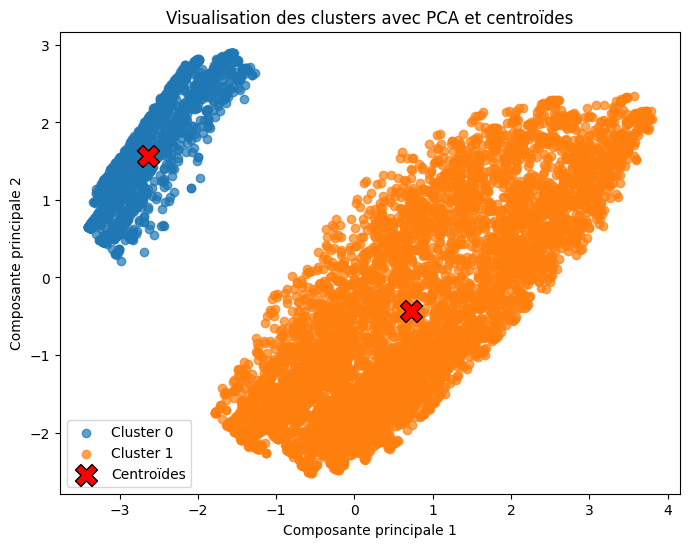

Variance expliquée par chaque composante : [0.32779794 0.20937571]
Variance totale expliquée : 0.5371736562162744


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_prepared)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

df_pca["Cluster"] = labels

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))

# Afficher les points des clusters
for cluster in sorted(df_pca["Cluster"].unique()):

    data = df_pca[df_pca["Cluster"] == cluster]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

# Afficher les centroïdes
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    color="red",
    edgecolors="black",
    label="Centroïdes"
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Visualisation des clusters avec PCA et centroïdes")
plt.legend()
plt.show()



In [109]:
df.to_csv("../data/processed/customer_clusters.csv",index=False)